In [3]:
# Imports 
import os
import time
import random
import pickle
import pandas as pd
import argparse
import numpy as np
import xgboost as xgb
import sklearn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from utils_model_training import merge_and_clean

In [4]:
# File directories

clinical_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv'))
features_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/full_radiomics_per_slice.csv'))
path_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/deeplearning_path.csv'))

# XGBoost


# Neural net
path_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/deeplearning_path.csv'))
checkpoint_path = os.path.expanduser('~/project/xAI-in-NSCLC/deep-learning results/Improved_Checkpoint_temporaryWeights.weights.h5')


In [5]:
features_df.shape

(7223, 662)

In [6]:
clinical_df.loc[clinical_df['Overall.Stage'].isna()]

,PatientID,age,clinical.T.Stage,Clinical.N.Stage,Clinical.M.Stage,Overall.Stage,Histology,gender,Survival.time,deadstatus.event
271,LUNG1-272,60.1396,5.0,2,0,NaN,large cell,male,288,1


In [7]:
path_df.loc[path_df['PatientID'] == 'LUNG1-272'].shape

(5, 3)

In [8]:
# Test train split before anything, used in both:

outcome = 'Overall.Stage'
mapping = {'I': 0, 'II': 0, 'IIIa':1, 'IIIb':1}

# Train test split by patient ID
temp_df = clinical_df.dropna(subset=[outcome])
X = temp_df['PatientID']
y = temp_df[outcome]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=240, stratify=y)

train_labels = X_train.unique()
test_labels = X_test.unique()

# XGBoost

if features_df is not None:
    #features_df = generate_features_table(features_df)

    # merging and cleaning datasets
    #mapping = {'adenocarcinoma': 0, 'squamous cell carcinoma': 1, 'large cell': 2, 'nos':3 }
    merged_df = merge_and_clean(features_df, clinical_df, mapping, outcome)
    # create test train split dfs for training
    X_train = merged_df.loc[merged_df['PatientID'].isin(train_labels)]
    print(len(X_train['PatientID'].unique()))
    y_train_xgb = X_train[outcome]
    X_test = merged_df.loc[merged_df['PatientID'].isin(test_labels)]
    print(len(X_test['PatientID'].unique()))
    y_test_xgb = X_test[outcome]

    X_train_xgb = X_train.drop(columns=['PatientID', outcome])#, 'slice_no'])
    X_test_xgb = X_test.drop(columns=['PatientID', outcome])#, 'slice_no'])


# Neural net

if path_df is not None:


    path_df = path_df.dropna(subset=[outcome])
    path_df[outcome] = path_df[outcome].map(mapping)
    print(f'Outcomes after mapping: {path_df[outcome].unique()}')
    # create test train split dfs for training
    X_train = path_df.loc[path_df['PatientID'].isin(train_labels)]
    y_train_nn = X_train[outcome]
    X_test = path_df.loc[path_df['PatientID'].isin(test_labels)]
    y_test_nn = X_test[outcome]

    X_train_nn = X_train.drop(columns='PatientID')
    X_test_nn = X_test.drop(columns='PatientID')


287
127
Outcomes after mapping: [1 0]


/home/coder/project/xAI-in-NSCLC/utils_model_training.py:141: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_clean[outcome] = merged_df_clean[outcome].map(mapping)


# XGBoost & SHAP

In [9]:
# imports

from utils_model_training import preprocessing_train, preprocessing_test, get_optimal_threshold, merge_and_clean, get_multiclass_results, get_stats_with_ci, generate_features_table



### Model Performance

In [10]:
#Reducing dataset to only the estimated features
with open("/home/coder/project/xAI-in-NSCLC/pyradiomics_savedmodels/gsearch_radiomics.pkl", "rb") as f:
    gsearch = pickle.load(f)
with open("/home/coder/project/xAI-in-NSCLC/pyradiomics_savedmodels/parameters_radiomics.pkl", "rb") as f:
    mean_std, selector, to_drop, support = pickle.load(f)

#[mean_std,selector, to_drop,support]

# reduced_features_train_set = 
# reduced_features_test_set = 

In [14]:
model = gsearch.best_estimator_
importances = model.feature_importances_
selected_features = X_train_xgb.columns[importances > 0]
print(selected_features)

IndexError: boolean index did not match indexed array along axis 0; size of axis is 661 but size of corresponding boolean axis is 13

In [ ]:
# SHAP values

explainer = shap.TreeExplainer(best_estimator)
shap_values = explainer(reduced_features_test_set)

if len(y_train.unique()) > 2:
    a = 1

else:
    import shap
    # beeswarm // whole model
    fig = shap.plots.beeswarm(shap_values, max_display=reduced_features_test_set.shape[1], plot_size=[10, 6], color=plt.get_cmap("cool"), show=False)
    plt.savefig('Model_shap.png', bbox_inches='tight')

    # getting indices of positive and negative predictions

    neg = y_test.loc[y_test == 0]
    pos = y_test.loc[y_test == 1]

    neg_list = neg.index
    pos_list = pos.index

    neg_idx = random.choice(neg_list)
    pos_idx = random.choice(pos_list)

    neg_idx = y_test.index.get_loc(neg_idx)
    pos_idx = y_test.index.get_loc(pos_idx)

    # negative plot
    fig, ax = plt.subplots()

    shap.plots.waterfall(shap_values[neg_idx], max_display=10, show=False)
    fig.set_size_inches(10, 6)
    fig = plt.gcf()
    fig.tight_layout()
    fig.savefig(str(path_to_save) + '/SHAP-figures/Negative_patient_shap.png', bbox_inches='tight')

    plt.close(fig)

    # positive plot
    fig, ax = plt.subplots()

    shap.plots.waterfall(shap_values[pos_idx], max_display=10, show=False) #reduced_features_test_set.shape[1] for full
    fig.set_size_inches(10, 6)
    fig = plt.gcf()
    fig.tight_layout()
    fig.savefig(str(path_to_save) + '/SHAP-figures/Positive_patient_shap.png', bbox_inches='tight')

    plt.close(fig)

    print('Saved SHAP analysis plots')

# Neural Net & Grad-CAM

In [7]:
# imports 

import tensorflow as tf
import seaborn as sns
import keras
import cv2
import sklearn
import pydicom
import random

from sklearn.metrics import auc, f1_score, roc_curve, recall_score, precision_score, accuracy_score, confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split
from keras.preprocessing import image
from keras.layers import Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import *
from keras.layers import Dense, GlobalAveragePooling2D, Flatten
from keras.models import Model
from keras import backend as K
from tensorflow.keras import layers, Model
from keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img

from IPython.display import Image, display
import matplotlib as mpl
import matplotlib.cm as cm


from utils_neuralnet import check_data_leakage, load_and_preprocess_dicom, make_gradcam_heatmap

I0000 00:00:1782221054.068130  749186 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782221054.162896  749186 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782221070.997582  749186 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Model performance

In [8]:
y_train = y_train_nn
y_test = y_test_nn
X_train = X_train_nn
X_test = X_test_nn

In [9]:
# Redefining the model and loading relevant weights

pre_trained_model1 = InceptionV3(include_top=False,
                                        weights= 'imagenet',
                                        input_shape = (299, 299, 3)) #Could I specify input size here?

for layer in pre_trained_model1.layers:
    layer.trainable = False

last_layer1 = pre_trained_model1.get_layer('mixed10')
print(f'last layer output shape: {last_layer1.output.shape}')
last_output1 = last_layer1.output

x = GlobalAveragePooling2D()(last_output1)
x = Flatten()(x)
x = Dense(1, activation=None)(x)

# x = layers.Flatten()(last_output1)
# x = layers.Dense(2048, activation='relu')(x)
# x = layers.Dense(1024, activation='relu')(x)
# x = layers.Dense(512, activation='relu')(x)
# x = layers.Dense(256, activation='relu')(x)
# x = layers.Dense(128, activation='relu')(x)
# x = layers.Dense(32, activation='relu')(x)
# x = layers.Dense(3, activation='softmax')(x) # originally: x = layers.Dense(1)(x)
# # x = layers.Activation(tf.nn.sigmoid)(x)


model1 = Model(pre_trained_model1.input, x)
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate= 0.001), loss='binary_crossentropy', metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
                        tf.keras.metrics.Precision(name='Precision'),
                        tf.keras.metrics.Recall(name='Recall'),
                        tf.keras.metrics.TruePositives(name='TP'),
                        tf.keras.metrics.TrueNegatives(name='TN'),
                        tf.keras.metrics.FalseNegatives(name='FN'),
                        tf.keras.metrics.FalsePositives(name='FP'),
                        tf.keras.metrics.AUC(name='AUC')])

model1.load_weights(checkpoint_path)

E0000 00:00:1782221078.168035  749186 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


last layer output shape: (None, 8, 8, 2048)


/home/coder/project/xAI-in-NSCLC/.venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [10]:
# Load your trained model
loaded_model = model1
last_conv_layer_name = "conv2d_93"

output_directory = '/home/coder/project/xAI-in-NSCLC/Grad-CAM figures'
patient = path_df.loc[path_df['PatientID'] == 'LUNG1-001']
fileNames = patient.path

In [11]:
# Some settings
img_size = (299, 299)
preprocess_input = keras.applications.xception.preprocess_input
decode_predictions = keras.applications.xception.decode_predictions

In [12]:
# load all of the test images & process them

#Converting to onehot encoding

# y_train = tf.keras.ops.one_hot(
#     y_train_nn, 3, axis=-1, dtype=None, sparse=False
# )
# y_test = tf.keras.ops.one_hot(
#     y_test, 3, axis=-1, dtype=None, sparse=False
# )

train_image_labels = X_train.loc[X_train['path'].str.endswith('.dcm'), 'path'].tolist()
train_images = np.array([load_and_preprocess_dicom(file)for file in train_image_labels])

test_image_labels = X_test.loc[X_test['path'].str.endswith('.dcm'), 'path'].tolist()
test_images = np.array([load_and_preprocess_dicom(file)for file in test_image_labels])

#Converting greyscale to rgb, InceptionV3 requires 3 channel input

print(f'Training set dimensions before: {train_images.shape}')
# img = img_array[0, :, :, 0]          # grayscale
# img_norm = (img - img.min()) / (img.max() - img.min())  # scale to 0–1
# img_rgb = np.stack([img_norm]*3, axis=-1)
# Fit on training set
train_min = train_images.min()
train_max = train_images.max()

# Apply to all sets
X_train = (train_images - train_min) / (train_max - train_min)
X_test  = (test_images  - train_min) / (train_max - train_min)

train_images = np.repeat(train_images[..., np.newaxis], 3, -1)

print(f'Training set dimensions after: {train_images.shape}')

print(f'\nTesting set dimensions before: {test_images.shape}')
test_images = np.repeat(test_images[..., np.newaxis], 3, -1)
print(f'Testing set dimensions after: {test_images.shape}')

Training set dimensions before: (4975, 299, 299)
Training set dimensions after: (4975, 299, 299, 3)

Testing set dimensions before: (2364, 299, 299)
Testing set dimensions after: (2364, 299, 299, 3)


In [ ]:
# # Model performance
# logits = model1(train_images)
# train_pred = tf.sigmoid(logits)
# #train_pred = loaded_model.predict(train_images)
# logits = model1(test_images)
# test_pred =tf.sigmoid(logits)
# #test_pred = loaded_model.predict(test_images)

W0000 00:00:1782221462.745034  749186 cpu_allocator_impl.cc:82] Allocation of 27521222400 exceeds 10% of free system memory.
W0000 00:00:1782221471.008436  749186 cpu_allocator_impl.cc:82] Allocation of 27521222400 exceeds 10% of free system memory.
W0000 00:00:1782221477.128369  749186 cpu_allocator_impl.cc:82] Allocation of 27521222400 exceeds 10% of free system memory.


In [ ]:
train_index = np.argmax(train_pred)
test_index = np.argmax(test_pred)

In [95]:
from utils_model_training import get_stats_with_ci, get_optimal_threshold

In [96]:
train_pred.shape

(4975, 1)

In [97]:
y_train_nn

0       1
1       1
2       1
3       1
4       1
       ..
7339    0
7340    0
7341    0
7342    0
7343    0
Name: Overall.Stage, Length: 4975, dtype: int64

In [98]:
threshold = get_optimal_threshold(y_train_nn, train_pred[:, 0], pos_label=1)
print(threshold)

Youden's index: 2.5057797614636e-08
2.5057798e-08


In [99]:
_, train_stats = get_stats_with_ci(y_train_nn, train_pred[:, 0], 'train_nn', threshold, nsamples=2000)
_, test_stats = get_stats_with_ci(y_test_nn, test_pred[:, 0], 'test_nn', threshold, nsamples=2000)

In [100]:
results_overall = pd.concat([train_stats, test_stats])
results_overall

,auc,accuracy,precision,specificity,recall,f1 score
train_nn,"0.58 CI [0.56,0.60]","2879/ 4975 ( 57 % ) CI [0.56,0.59]","2118/ 2719 ( 77 % ) CI [0.76,0.79]","761/ 1362 ( 55 % ) CI [0.53,0.59]","2118/ 3613 ( 58 % ) CI [0.57,0.60]","0/ 0 ( 66 % ) CI [0.66,0.68]"
test_nn,"0.61 CI [0.59,0.64]","1426/ 2364 ( 60 % ) CI [0.58,0.62]","1109/ 1419 ( 78 % ) CI [0.76,0.80]","317/ 627 ( 50 % ) CI [0.47,0.55]","1109/ 1737 ( 63 % ) CI [0.62,0.66]","0/ 0 ( 70 % ) CI [0.68,0.72]"


In [40]:
pred_binary = (test_pred[:, 0] > threshold).astype(int)
count_1 = pred_binary.sum()
count_0 = len(pred_binary) - count_1

print(count_0)
print(count_1)

945
1419


In [ ]:
with open("/home/coder/project/xAI-in-NSCLC/pyradiomics_savedmodels/proba_test_radiomics.pkl", "rb") as f:
    test_pred_xgb = pickle.load(f)
with open("/home/coder/project/xAI-in-NSCLC/pyradiomics_savedmodels/proba_train_radiomics.pkl", "rb") as f:
    train_pred_xgb = pickle.load(f)
with open("/home/coder/project/xAI-in-NSCLC/pyradiomics_savedmodels/y_test_radiomics.pkl", "rb") as f:
    y_test_xgb = pickle.load(f)
with open("/home/coder/project/xAI-in-NSCLC/pyradiomics_savedmodels/y_train_radiomics.pkl", "rb") as f:
    y_train_xgb = pickle.load(f)

# with open("/home/coder/project/xAI-in-NSCLC/pyradiomics_savedmodels/gsearch_radiomics.pkl", "rb") as f:
#     test_pred_xgb = pickle.load(f)

In [42]:
threshold_xgb = get_optimal_threshold(y_train_xgb, train_pred_xgb[:, 1], pos_label=1)
print(threshold_xgb)

Youden's index: 0.47780922055244446
0.47780922


In [43]:
_, train_stats = get_stats_with_ci(y_train_xgb, train_pred_xgb[:, 1], 'train_xgb', threshold_xgb, nsamples=2000)
_, test_stats = get_stats_with_ci(y_test_xgb, test_pred_xgb[:, 1], 'test_xgb', threshold_xgb, nsamples=2000)

In [44]:
results_overall = pd.concat([results_overall, train_stats, test_stats])

In [45]:
results_overall

,auc,accuracy,precision,specificity,recall,f1 score
train_nn,"0.58 CI [0.56,0.60]","2879/ 4975 ( 57 % ) CI [0.57,0.59]","2118/ 2719 ( 77 % ) CI [0.76,0.80]","761/ 1362 ( 55 % ) CI [0.53,0.58]","2118/ 3613 ( 58 % ) CI [0.57,0.60]","0/ 0 ( 66 % ) CI [0.66,0.68]"
test_nn,"0.61 CI [0.59,0.64]","1426/ 2364 ( 60 % ) CI [0.58,0.62]","1109/ 1419 ( 78 % ) CI [0.76,0.80]","317/ 627 ( 50 % ) CI [0.47,0.54]","1109/ 1737 ( 63 % ) CI [0.62,0.66]","0/ 0 ( 70 % ) CI [0.68,0.72]"
train_xgb,"0.90 CI [0.89,0.91]","4174/ 5048 ( 82 % ) CI [0.82,0.84]","3009/ 3265 ( 92 % ) CI [0.91,0.93]","1165/ 1421 ( 81 % ) CI [0.80,0.84]","3009/ 3627 ( 82 % ) CI [0.82,0.84]","0/ 0 ( 87 % ) CI [0.87,0.88]"
test_xgb,"0.59 CI [0.57,0.62]","1381/ 2170 ( 63 % ) CI [0.62,0.66]","1148/ 1460 ( 78 % ) CI [0.76,0.81]","233/ 545 ( 42 % ) CI [0.39,0.47]","1148/ 1625 ( 70 % ) CI [0.68,0.73]","0/ 0 ( 74 % ) CI [0.73,0.76]"


In [46]:
results_overall.to_csv('results_xgb_nn.csv', index=False)

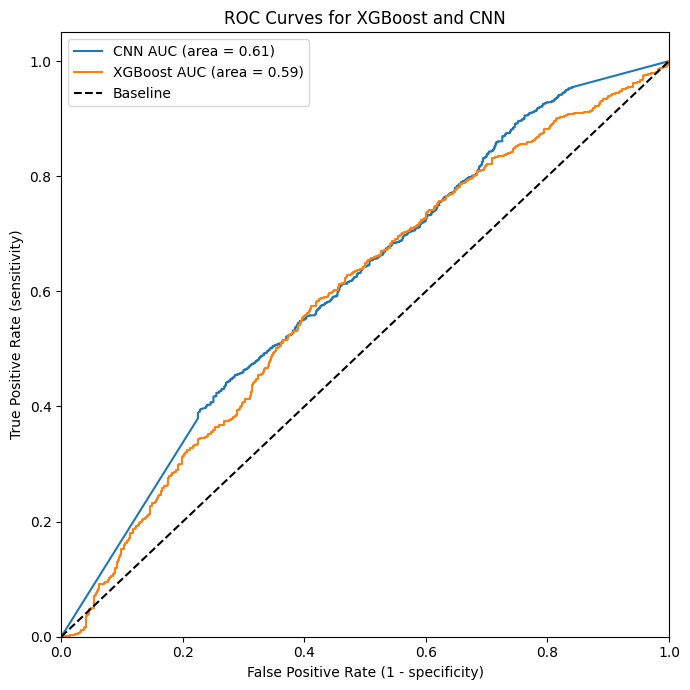

In [61]:
# Plot ROC curves for XGBoost and NN
from sklearn.metrics import roc_curve, auc



# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_nn, test_pred) 
roc_auc = auc(fpr, tpr)

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test_xgb, test_pred_xgb[:, 1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
fig, ax = plt.subplots(figsize=(7, 7))

# ROC Curve on ax1
ax.plot(fpr, tpr, label='CNN AUC (area = %0.2f)' % roc_auc)
ax.plot(fpr_xgb, tpr_xgb, label='XGBoost AUC (area = %0.2f)' % roc_auc_xgb)
ax.plot([0, 1], [0, 1], 'k--', label='Baseline')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - specificity)')
ax.set_ylabel('True Positive Rate (sensitivity)')
ax.set_title('ROC Curves for XGBoost and CNN')
ax.legend()

plt.tight_layout()
plt.show()

In [59]:
def get_ci_for_auc(label, pred, nsamples=2000):
    auc_values = []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    for b in range(nsamples):
        idx = np.random.randint(label.shape[0], size=label.shape[0])
        temp_pred = pred[idx]
        temp_fpr, temp_tpr, _ = sklearn.metrics.roc_curve(label.iloc[idx], temp_pred)
        auc_values.append(sklearn.metrics.auc(temp_fpr, temp_tpr))

        interp_tpr = np.interp(mean_fpr, temp_fpr, temp_tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

    tprs = np.array(tprs)
    mean_tpr = tprs.mean(axis=0)
    lower_tpr = np.percentile(tprs, 2.5, axis=0)
    upper_tpr = np.percentile(tprs, 97.5, axis=0)

    ci_auc = np.percentile(auc_values, (2.5, 97.5))
    fpr, tpr, _ = sklearn.metrics.roc_curve(label, pred)

    return mean_fpr, mean_tpr, lower_tpr, upper_tpr, auc_values, ci_auc


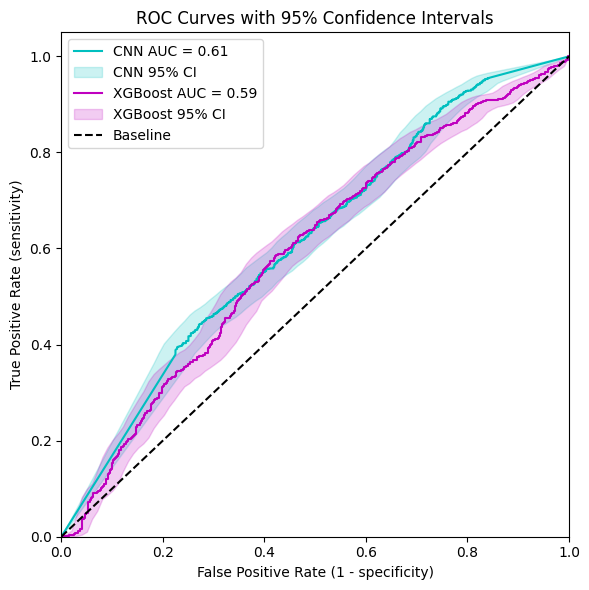

In [71]:
# Bootstrap CI for CNN
mean_fpr_cnn, mean_tpr_cnn, lower_cnn, upper_cnn, aucs_cnn, ci_auc_cnn = \
    get_ci_for_auc(y_test_nn, test_pred)

# Bootstrap CI for XGBoost
mean_fpr_xgb, mean_tpr_xgb, lower_xgb, upper_xgb, aucs_xgb, ci_auc_xgb = \
    get_ci_for_auc(y_test_xgb, test_pred_xgb[:, 1])

fig, ax = plt.subplots(figsize=(6, 6))

# CNN ROC
ax.plot(fpr, tpr, label=f'CNN AUC = {roc_auc:.2f}', color='c')
ax.fill_between(mean_fpr_cnn, lower_cnn, upper_cnn, alpha=0.2, label='CNN 95% CI', color='c')

# XGBoost ROC
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost AUC = {roc_auc_xgb:.2f}', color='m')
ax.fill_between(mean_fpr_xgb, lower_xgb, upper_xgb, alpha=0.2, label='XGBoost 95% CI', color='m')

# Baseline
ax.plot([0, 1], [0, 1], 'k--', label='Baseline')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - specificity)')
ax.set_ylabel('True Positive Rate (sensitivity)')
ax.set_title('ROC Curves with 95% Confidence Intervals')
ax.legend()

plt.tight_layout()
plt.show()


In [72]:
# Source - https://stackoverflow.com/a/52911181
# Posted by ImportanceOfBeingErnest, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-23, License - CC BY-SA 4.0

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D


def radar_factory(num_vars, frame='circle'):
    """Create a radar chart with `num_vars` axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle' | 'polygon'}
        Shape of frame surrounding axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarAxes(PolarAxes):

        name = 'radar'

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                    radius=.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            """ Draw. If frame is polygon, make gridlines polygon-shaped """
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)


        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                            spine_type='circle',
                            path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)


                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta


# N = len(data[0])
# theta = radar_factory(N, frame='polygon')

# spoke_labels = data.pop(0)
# title, case_data = data[0]

# fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='radar'))
# fig.subplots_adjust(top=0.85, bottom=0.05)

# ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
# ax.set_title(title,  position=(0.5, 1.1), ha='center')

# for d in case_data:
#     line = ax.plot(theta, d)
#     ax.fill(theta, d,  alpha=0.25)
# ax.set_varlabels(spoke_labels)

# plt.show()

In [101]:
# Make Grad cam for a positive case predicted correctly, and a negative case predicted correctly and both predicted incorrectly
# (or just one predicted incorrectly I guess)

path_df["split"] = path_df["PatientID"].isin(test_labels).map({True: "test", False: "train"})
test_df = path_df[path_df["split"] == "test"].copy()

test_df["prob"] = test_pred[:, 0]
test_df["pred"] = (test_df["prob"] > threshold).astype(int)
test_df["correct"] = (test_df["pred"] == test_df[outcome]).astype(int)

test_df

,PatientID,path,Overall.Stage,split,prob,pred,correct
64,LUNG1-004,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,0,test,5.224270e-18,0,1
65,LUNG1-004,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,0,test,5.218862e-05,1,0
66,LUNG1-004,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,0,test,2.827484e-21,0,1
67,LUNG1-004,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,0,test,3.195268e-29,0,1
68,LUNG1-004,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,0,test,3.160431e-01,1,0
...,...,...,...,...,...,...,...
7323,LUNG1-421,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,1,test,1.000000e+00,1,1
7324,LUNG1-421,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,1,test,9.999998e-01,1,1
7325,LUNG1-421,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,1,test,9.519437e-04,1,1
7326,LUNG1-421,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,1,test,8.403948e-07,1,1


In [102]:
sample_correct_0 = test_df[(test_df[outcome] == 0) & (test_df.correct == 1)].sample(1, random_state=204)
sample_correct_1 = test_df[(test_df[outcome] == 1) & (test_df.correct == 1)].sample(1, random_state=204)
sample_incorrect_0 = test_df[(test_df[outcome] == 0) & (test_df.correct == 0)].sample(1, random_state=204)
sample_incorrect_1 = test_df[(test_df[outcome] == 1) & (test_df.correct == 0)].sample(1, random_state=204)

selected = pd.concat([
    sample_correct_0,
    sample_correct_1,
    sample_incorrect_0,
    sample_incorrect_1
])

In [ ]:
selected
#LUNG1-159
#LUNG-214
#LUNG-261
#LUNG-226

,PatientID,path,Overall.Stage,split,prob,pred,correct
2770,LUNG1-159,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,0,test,0.000000e+00,0,1
3670,LUNG1-214,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,1,test,9.999999e-01,1,1
4505,LUNG1-263,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,0,test,3.610089e-06,1,0
3892,LUNG1-226,/home/coder/project/xAI-in-NSCLC/NSCLC-Radiomi...,1,test,4.397384e-13,0,0


In [104]:
train_df = path_df[path_df["split"] == "train"].reset_index(drop=True)
test_df  = path_df[path_df["split"] == "test"].reset_index(drop=True)

image_lookup = {}

for _, row in selected.iterrows():
    scan_id = row["PatientID"]

    if row["split"] == "train":
        idx = train_df.index[train_df["PatientID"] == scan_id][0]
        image_lookup[scan_id] = train_images[idx]
    else:
        idx = test_df.index[test_df["PatientID"] == scan_id][0]
        image_lookup[scan_id] = test_images[idx]


In [105]:
image_lookup

{'LUNG1-159': array([[[-1010, -1010, -1010],
         [ -989,  -989,  -989],
         [ -998,  -998,  -998],
         ...,
         [-1000, -1000, -1000],
         [-1001, -1001, -1001],
         [ -993,  -993,  -993]],
 
        [[ -986,  -986,  -986],
         [-1004, -1004, -1004],
         [ -994,  -994,  -994],
         ...,
         [ -997,  -997,  -997],
         [-1000, -1000, -1000],
         [ -999,  -999,  -999]],
 
        [[-1001, -1001, -1001],
         [ -999,  -999,  -999],
         [ -995,  -995,  -995],
         ...,
         [ -990,  -990,  -990],
         [-1004, -1004, -1004],
         [ -997,  -997,  -997]],
 
        ...,
 
        [[ -272,  -272,  -272],
         [ -277,  -277,  -277],
         [ -288,  -288,  -288],
         ...,
         [ -752,  -752,  -752],
         [ -771,  -771,  -771],
         [ -773,  -773,  -773]],
 
        [[ -450,  -450,  -450],
         [ -430,  -430,  -430],
         [ -430,  -430,  -430],
         ...,
         [ -840,  -840,  -

In [106]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]



    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [107]:
# # Grad-CAM
# for key in image_lookup.keys():

#     img_array = image_lookup[key]
#     label = selected.loc[selected['PatientID'] == key]['correct']
#     pred_index = int(label.iloc[0])
#     print(pred_index)

#     img_array = np.expand_dims(img_array, axis=0)
#     pred_index = np.argmax(model1.predict(img_array))
#     print(img_array.shape)
#     heatmap = make_gradcam_heatmap(img_array, model1, last_conv_layer_name)

#     # Normalize heatmap
#     heatmap = np.maximum(heatmap, 0)
#     heatmap /= heatmap.max()

#     # Convert to RGB
#     colormap = cm.get_cmap("jet")
#     heatmap_rgb = colormap(heatmap)[:, :, :3]


#     # Resize to match CT image
#     heatmap_rgb = cv2.resize(heatmap_rgb, (img_array.shape[2], img_array.shape[1]))
#     img = img_array[0, :, :, 0]          # grayscale
#     img_norm = (img - img.min()) / (img.max() - img.min())  # scale to 0–1
#     img_rgb = np.stack([img_norm]*3, axis=-1)                # make 3 channels

#     # Blend heatmap with original image
#     overlay = heatmap_rgb * 0.4 + img_rgb  # adjust alpha here

#     fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#     axes[0].imshow(img_rgb, cmap='gray')
#     axes[0].axis('off')
#     axes[0].set_title('Original Image')

#     axes[1].imshow(overlay)
#     axes[1].axis('off')
#     axes[1].set_title('Grad-CAM Overlay')

#     plt.show()

In [108]:
# Grad-CAM
for key in image_lookup.keys():

    img_array = image_lookup[key]
    label = selected.loc[selected['PatientID'] == key]['correct']
    pred_index = int(label.iloc[0])

    heatmap = make_gradcam_heatmap(np.expand_dims(img_array, axis=0), model1, last_conv_layer_name, pred_index=0)
    save_and_display_gradcam(img_array, heatmap, alpha=0.5)

ValueError: No such layer: conv2d_93. Existing layers are: ['input_layer_1', 'conv2d_94', 'batch_normalization_94', 'activation_94', 'conv2d_95', 'batch_normalization_95', 'activation_95', 'conv2d_96', 'batch_normalization_96', 'activation_96', 'max_pooling2d_4', 'conv2d_97', 'batch_normalization_97', 'activation_97', 'conv2d_98', 'batch_normalization_98', 'activation_98', 'max_pooling2d_5', 'conv2d_102', 'batch_normalization_102', 'activation_102', 'conv2d_100', 'conv2d_103', 'batch_normalization_100', 'batch_normalization_103', 'activation_100', 'activation_103', 'average_pooling2d_9', 'conv2d_99', 'conv2d_101', 'conv2d_104', 'conv2d_105', 'batch_normalization_99', 'batch_normalization_101', 'batch_normalization_104', 'batch_normalization_105', 'activation_99', 'activation_101', 'activation_104', 'activation_105', 'mixed0', 'conv2d_109', 'batch_normalization_109', 'activation_109', 'conv2d_107', 'conv2d_110', 'batch_normalization_107', 'batch_normalization_110', 'activation_107', 'ac

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [84]:
def save_and_display_gradcam(img, heatmap, cam_path="cam.jpg", alpha=0.4):

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = mpl.colormaps["jet"]

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    # Save the superimposed image
    superimposed_img.save(cam_path)

    # Display Grad CAM
    display(Image(cam_path))